In [33]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/Student Performance Factors Actividad 1.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Actividad 2 - Algoritmos de Aprendizaje Automático

**Nombre:** Héctor Emiliano Leal Prieto  
**Dataset:** Student Performance Factors Dataset  
**Fuente:** Kaggle  
**Enlace:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  

## Introducción

En esta actividad se utilizará el dataset **Student Performance Factors Dataset** para construir y comparar modelos de regresión que permitan estimar la variable **Exam_Score** a partir de diferentes características académicas, personales y escolares de los estudiantes.

## Descripción del análisis

Cada registro representa a un estudiante y contiene información sobre factores académicos, personales, familiares y escolares.

**Variable objetivo:** `Exam_Score`, que representa el puntaje obtenido por cada estudiante en el examen.

**Pregunta predictiva:**  
¿En qué medida las características de los estudiantes permiten estimar su puntaje de examen?

In [34]:
import pandas as pd
df = pd.read_csv(dataset_path)

print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

## Revisión inicial del dataset

Se revisará la estructura general del dataset, incluyendo el número de registros, las variables disponibles, sus tipos de datos, los valores faltantes y los posibles registros duplicados.

In [35]:
# Número de registros y columnas
df.shape

(6607, 20)

In [36]:
# Variables disponibles
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [37]:
# Tipos de datos
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [38]:
# Valores faltantes
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [39]:
# Duplicados
df.duplicated().sum()

np.int64(0)

## Limpieza de datos

Se realizará una limpieza básica eliminando registros duplicados, valores faltantes en la variable objetivo y valores de `Exam_Score` fuera del rango válido de 0 a 100. Los valores faltantes de las variables predictoras se tratarán posteriormente durante el preprocesamiento.

In [40]:
# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar registros sin valor en Exam_Score
df = df.dropna(subset=['Exam_Score'])

# Ajustar puntajes mayores a 100 al máximo permitido
df.loc[df['Exam_Score'] > 100, 'Exam_Score'] = 100

# Dimensiones despues de la limpieza
df.shape

(6607, 20)

## Exploración de la variable objetivo

Se analizará la variable `Exam_Score` mediante estadísticas descriptivas y un histograma para observar cómo se distribuyen los puntajes de los estudiantes.

In [41]:
df["Exam_Score"].describe()

,Exam_Score
count,6607.000000
mean,67.235508
std,3.889161
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,100.000000


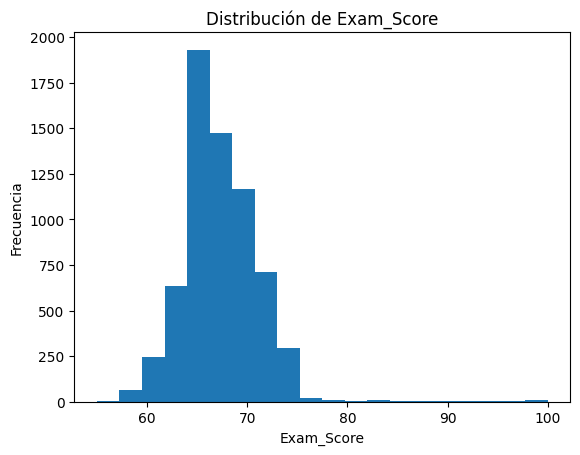

In [42]:
# Histograma
import matplotlib.pyplot as plt

plt.hist(df["Exam_Score"], bins=20)
plt.xlabel("Exam_Score")
plt.ylabel("Frecuencia")
plt.title("Distribución de Exam_Score")
plt.show()

El histograma permite observar en qué rango se concentran la mayoría de los puntajes y si existen valores poco frecuentes en los extremos de la distribución.

## Relación entre variables

Se analizará la relación entre `Exam_Score` y algunas variables predictoras mediante una matriz de correlación y gráficas.

La matriz de correlación permite observar qué variables numéricas presentan una mayor relación con el puntaje del examen. También se utilizará un diagrama de dispersión para observar la relación entre las horas estudiadas y el puntaje, y un diagrama de caja para comparar los puntajes según el nivel de motivación.

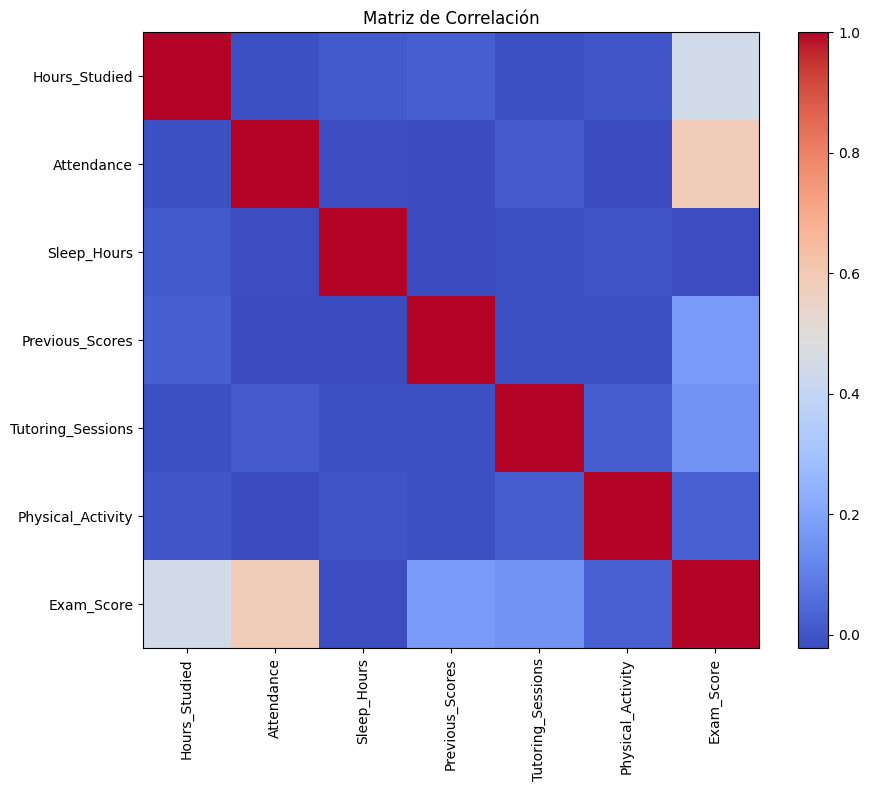

In [43]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title('Matriz de Correlación')
plt.show()

In [44]:
correlation["Exam_Score"].sort_values(ascending=False)

,Exam_Score
Exam_Score,1.000000
Attendance,0.581205
Hours_Studied,0.445558
Previous_Scores,0.175089
Tutoring_Sessions,0.156466
Physical_Activity,0.027832
Sleep_Hours,-0.017000


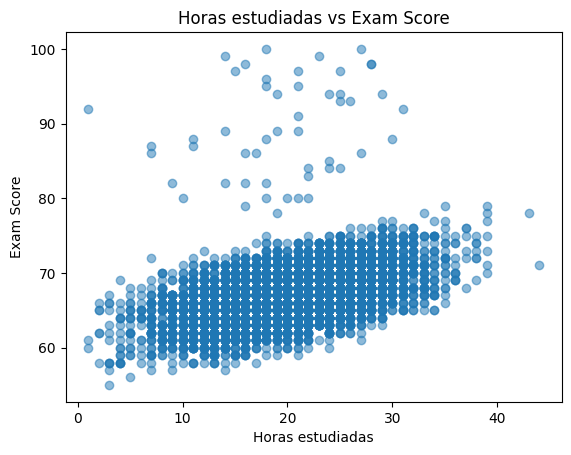

In [45]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.5)

plt.xlabel("Horas estudiadas")
plt.ylabel("Exam Score")
plt.title("Horas estudiadas vs Exam Score")

plt.show()

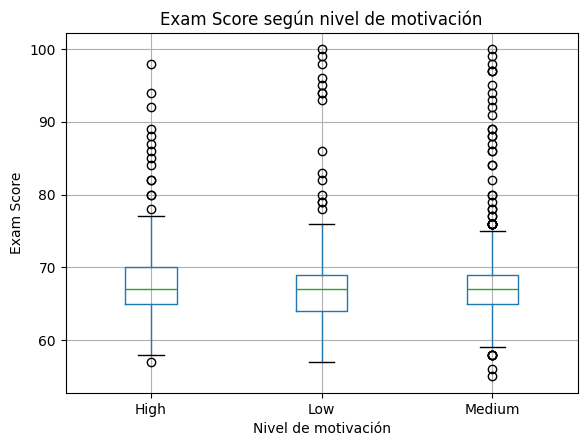

In [46]:
df.boxplot(column="Exam_Score", by="Motivation_Level")

plt.xlabel("Nivel de motivación")
plt.ylabel("Exam Score")
plt.title("Exam Score según nivel de motivación")
plt.suptitle("")

plt.show()

## Selección de variables

Para el modelado se utilizarán las siguientes variables:

- `Hours_Studied`: las horas de estudio pueden influir directamente en el desempeño del estudiante.
- `Attendance`: una mayor asistencia puede estar relacionada con mejores resultados académicos.
- `Previous_Scores`: permite considerar el rendimiento académico previo del estudiante.
- `Tutoring_Sessions`: las sesiones de tutoría pueden contribuir a mejorar el desempeño.
- `Motivation_Level`: el nivel de motivación puede afectar el esfuerzo y rendimiento del estudiante.
- `Access_to_Resources`: contar con mejores recursos puede facilitar el aprendizaje.

Estas variables fueron seleccionadas porque presentan una relación razonable con el desempeño académico y permiten utilizar tanto información numérica como categórica para predecir `Exam_Score`.

## División de datos

Se definieron las variables predictoras en `X` y la variable objetivo `Exam_Score` en `y`.

El dataset se dividió en 80 % para entrenamiento y 20 % para prueba. Se utilizó `random_state=42` para mantener la misma división cada vez que se ejecute el notebook y obtener resultados reproducibles.

In [47]:
from sklearn.model_selection import train_test_split

# Varoles Predictoras
X = df[
    [
        "Hours_Studied",
        "Attendance",
        "Previous_Scores",
        "Tutoring_Sessions",
        "Motivation_Level",
        "Access_to_Resources"
    ]
]

# Variable Objetivo
y = df["Exam_Score"]

# División de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5285, 6)
Prueba: (1322, 6)


## Preprocesamiento de variables

Se construyó un flujo de preprocesamiento para aplicar diferentes transformaciones según el tipo de variable.

Las variables numéricas serán imputadas y escaladas, mientras que las variables categóricas serán imputadas y convertidas a valores numéricos mediante One-Hot Encoding.

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Variables numéricas
numericas = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions"
]

# Variables categóricas
categoricas = [
    "Access_to_Resources"
]

# Variable categórica ordinal
ordinales = [
    "Motivation_Level"
]

# Preprocesamiento numérico
pipeline_numerico = Pipeline([
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico
pipeline_categorico = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("codificacion", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesamiento categórico ordinal
pipeline_ordinal = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("codificacion", OrdinalEncoder(
        categories = [["Low", "Medium", "High"]]
    ))
])

# Unir ambos preprocesamientos
preprocesador = ColumnTransformer([
    ("numericas", pipeline_numerico, numericas),
    ("categóricas", pipeline_categorico, categoricas),
    ("ordinal", pipeline_ordinal, ordinales)
])

## Línea base

Se utilizó `DummyRegressor` con la media de `Exam_Score` como línea base. Este modelo predice siempre el promedio de los puntajes del conjunto de entrenamiento y servirá como referencia para comparar los modelos de regresión.

In [49]:
from sklearn.dummy import DummyRegressor

# Crear línea base
linea_base = DummyRegressor(strategy="mean")

# Entrenar con los datos de información
linea_base.fit(X_train, y_train)

# Realizar predicciones
pred_base = linea_base.predict(X_test)

## Entrenamiento de modelos

Se entrenaron dos modelos de regresión utilizando el mismo conjunto de entrenamiento y prueba:

- Regresión Lineal.
- Regresión Ridge.

En ambos casos se utilizó el flujo de preprocesamiento definido anteriormente para transformar las variables antes de entrenar el modelo.

In [50]:
from sklearn.linear_model import LinearRegression, Ridge

# Regresión lineal
modelo_lineal = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LinearRegression())
])

# Regresión Ridge
modelo_ridge = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", Ridge())
])

# Entrenar los modelos
modelo_lineal.fit(X_train, y_train)
modelo_ridge.fit(X_train, y_train)

# Realizar predicciones
pred_lineal = modelo_lineal.predict(X_test)
pred_ridge = modelo_ridge.predict(X_test)

## Evaluación de los modelos

Se evaluaron la línea base, la regresión lineal y el modelo Ridge utilizando las métricas MAE, RMSE y R².

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Línea base
mae_base = mean_absolute_error(y_test, pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
r2_base = r2_score(y_test, pred_base)

# Regresión lineal
mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))
r2_lineal = r2_score(y_test, pred_lineal)

# Ridge
mae_ridge = mean_absolute_error(y_test, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

# Tabla de resultados
resultados = pd.DataFrame({
    "Modelo": ["Línea Base", "Regresión lineal", "Ridge"],
    "MAE": [mae_base, mae_lineal, mae_ridge],
    "RMSE": [rmse_base, rmse_lineal, rmse_ridge],
    "R2": [r2_base, r2_lineal, r2_ridge]
})

resultados.round(3)

,Modelo,MAE,RMSE,R2
0,Línea Base,2.823,3.761,-0.001
1,Regresión lineal,1.081,2.114,0.684
2,Ridge,1.082,2.114,0.684


# Interpretación de métricas

### Mean absolute Error (MSE)
El **MAE** indica cuántos puntos se alejan, en promedio, las predicciones del valor real de Exam_Score. La línea base obtuvo un MAE de **2.823 puntos**, mientras que la regresión lineal obtuvo **1.081** y Ridge **1.082**. Esto significa que los modelos entrenados reducen considerablemente el error promedio y suelen equivocarse aproximadamente **1 punto** en una escala de hasta 100.

### Root Mean Squared Error (RMSE)
El **RMSE** penaliza con mayor intensidad los errores grandes porque los errores se elevan al cuadrado durante su cálculo. La línea base obtuvo un RMSE de **3.761**, mientras que ambos modelos obtuvieron aproximadamente **2.114**. El hecho de que el RMSE sea mayor que el MAE indica que existen algunos casos donde los errores son más grandes que el promedio.

### R² - R-squared (Coeficiente de Determinación)
El **R²** indica qué proporción de la variación de Exam_Score puede explicar el modelo. La línea base obtuvo un valor de **-0.001**, lo que indica que prácticamente no aporta capacidad predictiva. En cambio, la regresión lineal y Ridge obtuvieron un **R² de 0.684**, por lo que explican aproximadamente el **68.4 % de la variación** de los puntajes.

La regresión lineal obtuvo resultados ligeramente mejores que Ridge, aunque la diferencia es mínima. Comparada con la línea base, redujo el MAE aproximadamente **62%** por lo que representa una mejora importante para estimar el desempeño académico.

## Valores reales, predicciones y residuos

Se compararon los valores reales de `Exam_Score` con las predicciones realizadas por la Regresión Lineal y Ridge.

Además, se analizaron los residuos de la Regresión Lineal, ya que fue el modelo con el menor error.

### Valores reales vs. predichos - Regresión Lineal

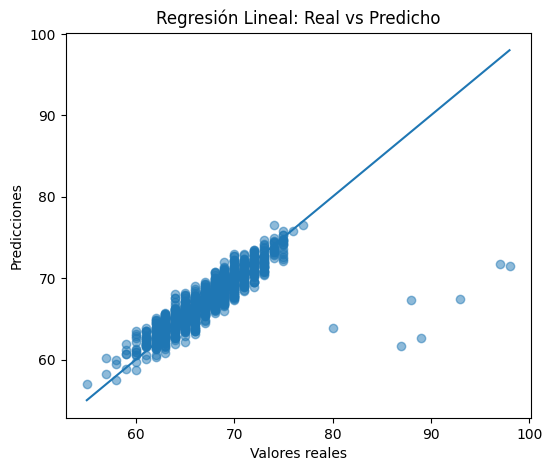

In [52]:
plt.figure(figsize=(6, 5))

plt.scatter(y_test, pred_lineal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Real vs Predicho")

plt.show()

### Valores reales vs. predichos - Ridge

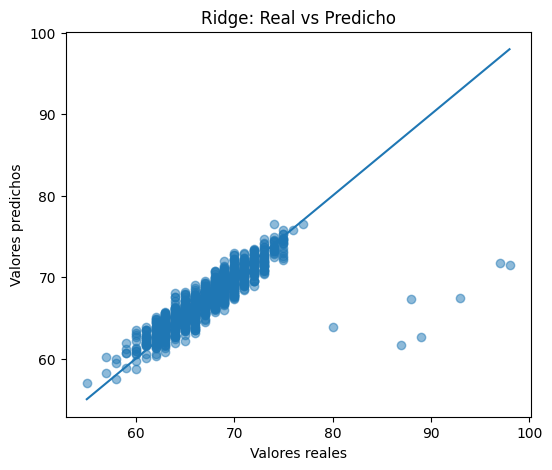

In [53]:
plt.figure(figsize=(6, 5))

plt.scatter(y_test, pred_ridge, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Ridge: Real vs Predicho")

plt.show()

### Residuos de la regresión lineal

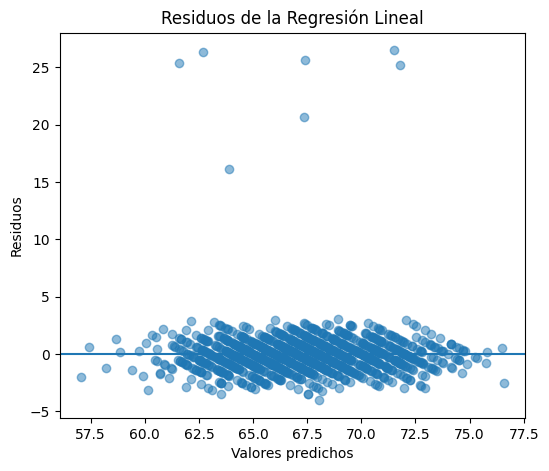

In [54]:
residuos = y_test - pred_lineal

plt.figure(figsize=(6, 5))

plt.scatter(pred_lineal, residuos, alpha=0.5)
plt.axhline(y=0)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos de la Regresión Lineal")

plt.show()

### Análisis de residuos

La mayoría de los residuos de la Regresión Lineal se encuentran cerca de cero, lo que indica que el modelo realiza predicciones relativamente precisas para la mayoría de los estudiantes.

Sin embargo, se observan algunos valores extremos con residuos positivos de más de 15 puntos. Estos casos corresponden principalmente a estudiantes con puntajes de examen muy altos, los cuales el modelo tiende a subestimar.

Por lo tanto, aunque los errores se distribuyen de manera relativamente estable para la mayoría de los datos, el modelo presenta mayores dificultades para estimar correctamente los puntajes más altos.

## Comparación de errores

Se compararon algunas observaciones con los errores absolutos más altos y otras con predicciones más precisas para identificar posibles diferencias entre sus características.

In [55]:
comparacion = X_test.copy()

comparacion["Real"] = y_test
comparacion["Predicho"] = pred_lineal
comparacion["Error_Absoluto"] = abs(y_test - pred_lineal)

# Casos con mayor error
mayores_errores = comparacion.sort_values(
    "Error_Absoluto",
    ascending=False
).head(5)

mayores_errores

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Motivation_Level,Access_to_Resources,Real,Predicho,Error_Absoluto
4192,28,90,91,0,Medium,Medium,98,71.507230,26.492770
217,19,70,54,0,High,Low,89,62.690844,26.309156
4531,26,69,95,0,Low,High,93,67.385485,25.614515
2687,11,71,55,1,Medium,Medium,87,61.601996,25.398004
5966,25,99,77,0,Medium,Medium,97,71.772494,25.227506


In [56]:
menores_errores = comparacion.sort_values(
    "Error_Absoluto"
).head(5)

menores_errores

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Motivation_Level,Access_to_Resources,Real,Predicho,Error_Absoluto
6253,22,85,96,0,Medium,Medium,69,69.000606,0.000606
834,20,96,71,5,Medium,Medium,72,72.001118,0.001118
2543,18,91,63,1,Medium,Medium,68,67.998670,0.001330
5803,31,93,80,3,Medium,Medium,74,73.998640,0.001360
6577,14,73,57,2,High,Medium,64,63.998613,0.001387


### Análisis de errores

Los casos con mayor error tienen algo en común: todos presentan un `Exam_Score` real muy alto, entre **87 y 98 puntos**, mientras que el modelo predice valores aproximadamente entre **62 y 72 puntos**. Esto muestra que la Regresión Lineal tiende a **subestimar a los estudiantes con resultados excepcionalmente altos**.

Por ejemplo, el estudiante con índice 4192 obtuvo **98 puntos**, pero el modelo predijo aproximadamente **71.5**, generando un error de más de **26 puntos**, aunque tenía 28 horas de estudio, 90 de asistencia y un puntaje previo de 91.

En cambio, los casos con menor error presentan diferencias casi nulas entre el valor real y el predicho. Por ejemplo, para el índice 6253 el valor real fue **69** y la predicción fue aproximadamente **69.001**.

Las características de los casos con mayor error son variadas, por lo que no parece existir una sola variable responsable. Algunos tienen alta asistencia, muchas horas de estudio o puntajes previos elevados, mientras que otros no. Esto sugiere que las variables seleccionadas no explican completamente por qué ciertos estudiantes alcanzan resultados tan altos.

También puede existir una limitación del modelo, ya que la Regresión Lineal tiende a producir predicciones cercanas al comportamiento general de los datos y tiene dificultades para representar casos extremos. Por lo tanto, las diferencias observadas parecen estar relacionadas principalmente con **las variables disponibles y las limitaciones del modelo**, más que con el preprocesamiento utilizado.

## Validación cruzada

Se aplicó validación cruzada k-fold con 5 particiones al modelo de Regresión Lineal, utilizando únicamente el conjunto de entrenamiento.

Se utilizó MAE como métrica para observar qué tanto cambia el error del modelo entre diferentes particiones de los datos.

In [57]:
from sklearn.model_selection import cross_val_score

# Validación cruzada de 5 particiones
scores = -cross_val_score(
    modelo_lineal,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("MAE de cada partición:", scores)
print("MAE promedio:", scores.mean())
print("Desviación estándar:", scores.std())
print("MAE prueba:", mae_lineal)

MAE de cada partición: [1.11075816 1.08504036 1.1667779  1.21826148 1.26883871]
MAE promedio: 1.1699353220695614
Desviación estándar: 0.06758159502496494
MAE prueba: 1.081497255526964


### Interpretación de la validación cruzada

La validación cruzada obtuvo valores de MAE entre **1.085 y 1.269 puntos**, con un promedio de **1.170** y una desviación estándar de **0.068**.

El MAE promedio de la validación cruzada es ligeramente mayor que el MAE de **1.081** obtenido con la división original de entrenamiento y prueba. Esto indica que el resultado inicial fue un poco mejor que el desempeño promedio observado en otras particiones.

La desviación estándar es baja, por lo que el desempeño del modelo se mantiene relativamente estable entre las diferentes particiones de los datos.

La validación cruzada proporciona una referencia más confiable porque evalúa el modelo varias veces con diferentes divisiones, evitando depender únicamente del resultado obtenido en una sola partición de entrenamiento y prueba.

# Conclusión

La **Regresión Lineal** obtuvo el mejor desempeño, aunque sus resultados fueron casi idénticos a los de Ridge. La regresión lineal alcanzó un **MAE de 1.081**, un **RMSE de 2.114** y un **R² de 0.684**, superando claramente a la línea base, que obtuvo un MAE de **2.823**. Esto representa una reducción aproximada del **62% en el error absoluto promedio**.

Entre las variables utilizadas, Hours_Studied, Attendance y Previous_Score parecen ser especialmente relevantes para explicar el desempeño académico, aunque también se incluyeron `Tutoring_lessons`, `Motivation_Level` y `Access_to_resources`.

Una de las principales limitaciones observadas fue que el modelo tuvo dificultades para predecir correctamente los puntajes más altos. Algunos estudiantes con valores reales cercanos a 90 o 100 fueron subestimados por más de 20 puntos. Esto sugiere que las variables seleccionadas no explican completamente todos los factores que influyen en los resultados excepcionales y que un modelo lineal puede no representar todas las relaciones presentes en los datos.

Como mejora futura, se podrían incluir más variables del dataset y probar modelos capaces de representar relaciones más complejas, como un árbol de regresión o modelos de ensamble.

La validación cruzada obtuvo un MAE promedio de **1.170** con una desviación estándar de **0.068**, lo que indica que el desempeño del modelo es relativamente estable entre diferentes particiones de los datos.

En conclusión, la Regresión Lineal puede considerarse una **buena primera aproximación** para estimar `Exam_Score`, pero requiere mayor validación y comparación con otros modelos antes de utilizarse para apoyar decisiones académicas reales.